# Microscopy Analysis — Test Tube & 24-Well

This notebook examines the effect of bead treatment on cell morphology using DIC microscopy images from test-tube and 24-well experiments. Single-cell measurements (area and major-axis length) are pooled across wells and replicates for each volume and bead condition. Grouped bar charts compare mean morphology between bead and no-bead conditions at each culture volume, with statistical comparisons made explicit using Holm-Bonferroni-corrected Welch's t-tests.

In [1]:
from pathlib import Path

import arcadia_pycolor as apc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

apc.mpl.setup()

## Statistical setup

The two helper functions below handle p-value correction and figure annotation. Raw p-values from Welch's t-tests are adjusted using Holm-Bonferroni correction and converted to star notation (`*` p < 0.05, `**` p < 0.01, `***` p < 0.001) placed above the relevant bars in each figure.

In [2]:
def pval_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


def correct_pvalues(pvals):
    """Apply Holm-Bonferroni correction, tolerating NaNs."""
    valid_mask = [not np.isnan(p) for p in pvals]
    if not any(valid_mask):
        return list(pvals)
    valid_pvals = [p for p, v in zip(pvals, valid_mask, strict=True) if v]
    _, corrected, _, _ = multipletests(valid_pvals, method="holm")
    corrected_iter = iter(corrected)
    return [next(corrected_iter) if v else np.nan for v in valid_mask]

## Data preparation

Measurements are loaded from `data/microscopy/combined_dic_measurements_ttubes.csv` and `data/microscopy/combined_dic_measurements_24well.csv`. Each row represents a single segmented cell. The `bead_present` column distinguishes bead from no-bead conditions, and `volume_ml` gives the culture volume. The samples below are a quick sanity check that the expected columns are present.

In [3]:
REPO_ROOT = Path().resolve().parent

df_tt = pd.read_csv(REPO_ROOT / "data" / "microscopy" / "combined_dic_measurements_ttubes.csv")
df_24 = pd.read_csv(REPO_ROOT / "data" / "microscopy" / "combined_dic_measurements_24well.csv")

print(f"Test tubes: {len(df_tt):,} cells")
df_tt.sample(5, random_state=42).drop("source_file", axis=1)

Test tubes: 41,742 cells


,axis_major_length,area,length,well_letter,well_num,strain,treatment,volume_ml,volume_group,bead_present
21388,19.181005,66.622969,19.181005,E,7,SP286,2 mL bead,2,b,True
40911,16.505401,57.143125,16.505401,F,10,SP286,5 mL bead,5,e,True
14084,10.688434,41.272969,10.688434,E,1,SP286,1 mL no bead,1,a,False
38362,12.400003,42.593281,12.400003,F,9,SP286,4 mL bead,4,d,True
29694,8.032724,29.126094,8.032724,F,2,SP286,2 mL no bead,2,b,False


In [4]:
print(f"24-well: {len(df_24):,} cells")
df_24.sample(5, random_state=42).drop("source_file", axis=1)

24-well: 42,648 cells


,axis_major_length,area,length,well_letter,well_num,strain,treatment,volume_ml,volume_group,bead_present
1900,13.528859,42.514063,13.528859,D,3,SP286,3 mL no bead,3,c,False
20628,11.552368,40.322344,11.552368,E,6,SP286,1 mL bead,1,a,True
33411,13.626529,49.749375,13.626529,F,5,SP286,5 mL no bead,5,e,False
40176,15.837376,57.882500,15.837376,F,9,SP286,4 mL bead,4,d,True
14421,8.744678,28.439531,8.744678,E,2,SP286,2 mL no bead,2,b,False


## Cell morphology by volume and bead condition

`plot_metric_by_volume` produces a grouped bar chart of the mean value of any continuous morphology column, with volume on the x-axis and separate bars for bead vs. no-bead conditions. Error bars are approximate 95% confidence intervals (1.96 × SEM). Significance stars reflect Holm-Bonferroni-corrected Welch's t-tests comparing bead to no-bead within each volume.

In [5]:
METRIC_LABELS = {
    "area": "area (\u03bcm\u00b2)",
    "length": "length (\u03bcm)",
}

BEAD_LABELS = {False: "no bead", True: "bead"}


def plot_metric_by_volume(df, metric, title, output_filename):
    """Grouped bar plot of mean `metric` by volume with bead vs. no-bead,
    annotated with Holm-Bonferroni-corrected Welch's t-tests."""
    volumes = sorted(df["volume_ml"].unique())
    conditions = [False, True]

    means = df.groupby(["volume_ml", "bead_present"])[metric].mean().unstack()
    stds = df.groupby(["volume_ml", "bead_present"])[metric].std().unstack()
    counts = df.groupby(["volume_ml", "bead_present"])[metric].count().unstack()
    cis = 1.96 * stds / np.sqrt(counts)

    x = np.arange(len(volumes))
    bar_w = 0.8 / len(conditions)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=apc.parchment)
    for i, cond in enumerate(conditions):
        ax.bar(
            x + (i - (len(conditions) - 1) / 2) * bar_w,
            means[cond],
            width=bar_w,
            label=BEAD_LABELS[cond],
            yerr=cis[cond],
            capsize=6,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in volumes])
    ax.set_xlabel("Volume (mL)")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.set_title(f"Mean cell {metric} by volume ({title})")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    raw_pvals = []
    for v in volumes:
        ctrl = df[(df["volume_ml"] == v) & (~df["bead_present"])][metric].values
        treat = df[(df["volume_ml"] == v) & (df["bead_present"])][metric].values
        if len(ctrl) > 1 and len(treat) > 1:
            _, p = ttest_ind(ctrl, treat, equal_var=False)
        else:
            p = np.nan
        raw_pvals.append(p)

    adj_pvals = correct_pvalues(raw_pvals)
    y_offset = means.max().max() * 0.03
    for v, adj_p in zip(volumes, adj_pvals, strict=True):
        stars = pval_to_stars(adj_p)
        if stars:
            vi = volumes.index(v)
            ctrl_pos = x[vi] + (conditions.index(False) - (len(conditions) - 1) / 2) * bar_w
            treat_pos = x[vi] + (conditions.index(True) - (len(conditions) - 1) / 2) * bar_w
            y_max = max(
                means.loc[v, False] + cis.loc[v, False],
                means.loc[v, True] + cis.loc[v, True],
            )
            ax.text(
                (ctrl_pos + treat_pos) / 2,
                y_max + y_offset,
                stars,
                ha="center",
                va="bottom",
                fontsize=14,
            )

    # Set y-axis limit for better clarity and space for annotations
    y_max = means.max().max() + cis.max().max() + y_offset * 6
    ax.set_ylim(0, y_max)

    # Apply custom plot styling and layout
    apc.mpl.style_plot(ax)
    plt.tight_layout()

    # Save the figure
    svg_out = REPO_ROOT / "figures" / output_filename
    fig.savefig(svg_out, bbox_inches="tight", facecolor=apc.parchment)

    return fig

## Test tube experiment

### Cell area

Mean cross-sectional area (μm²) per volume, comparing bead to no-bead conditions.

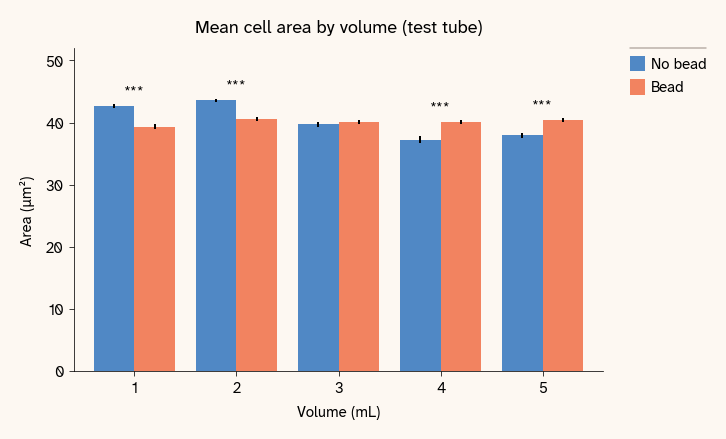

In [6]:
fig_tt_area = plot_metric_by_volume(df_tt, "area", "test tube", "ttube_bar_plot_area.svg")

### Cell length

Mean major-axis length (μm) per volume, comparing bead to no-bead conditions.

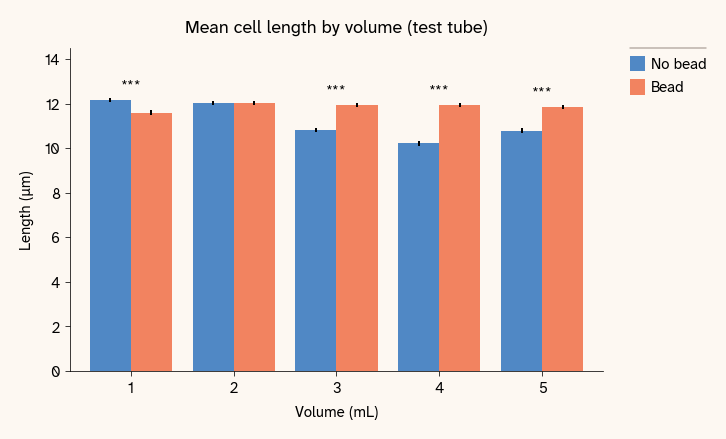

In [7]:
fig_tt_length = plot_metric_by_volume(df_tt, "length", "test tube", "ttube_bar_plot_length.svg")

## 24-well experiment

### Cell area

Mean cross-sectional area (μm²) per volume, comparing bead to no-bead conditions.

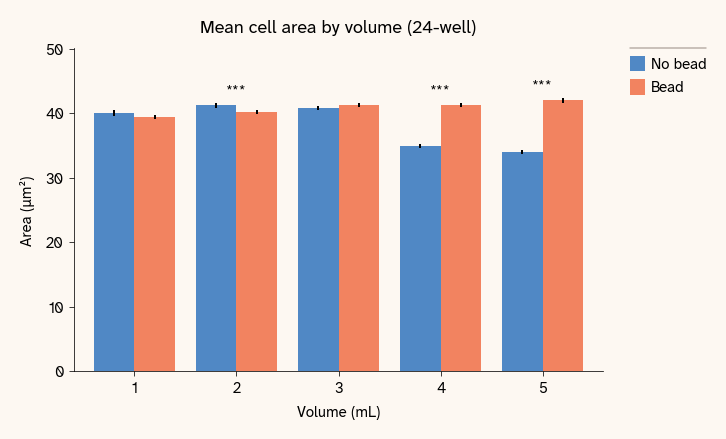

In [8]:
fig_24_area = plot_metric_by_volume(df_24, "area", "24-well", "24-well_bar_plot_area.svg")

### Cell length

Mean major-axis length (μm) per volume, comparing bead to no-bead conditions.

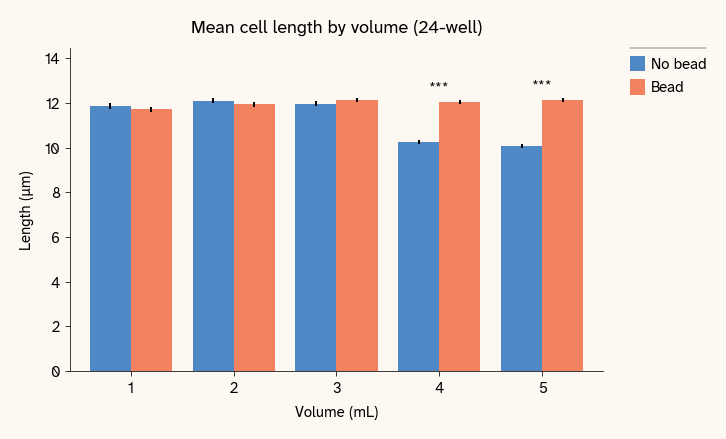

In [9]:
fig_24_length = plot_metric_by_volume(df_24, "length", "24-well", "24-well_bar_plot_length.svg")